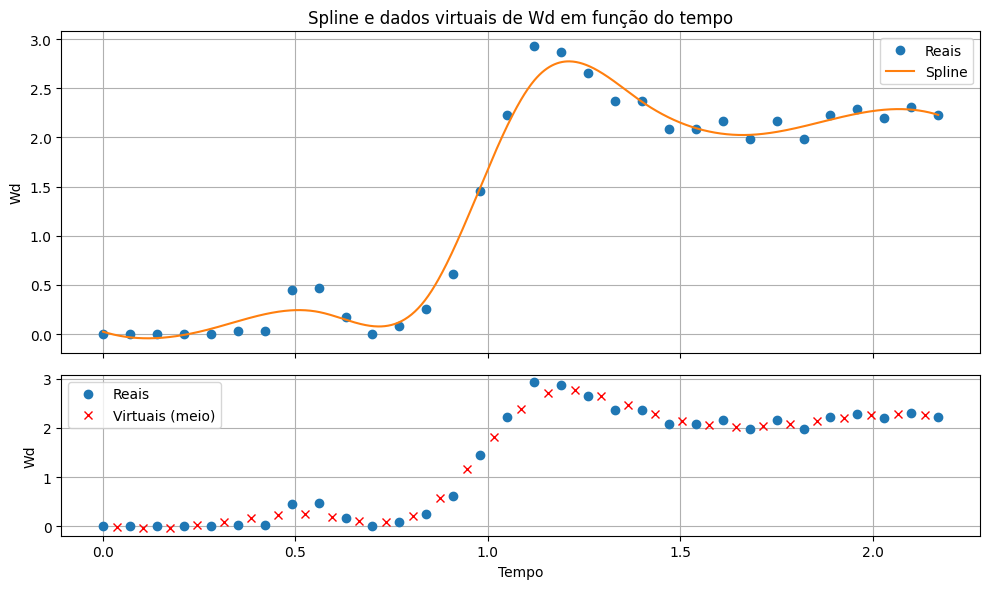

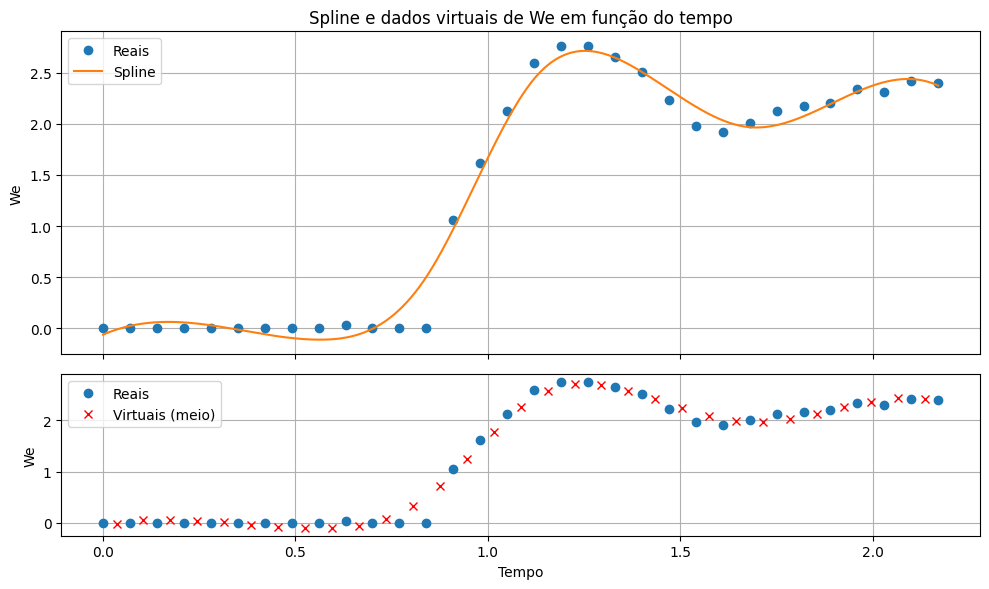

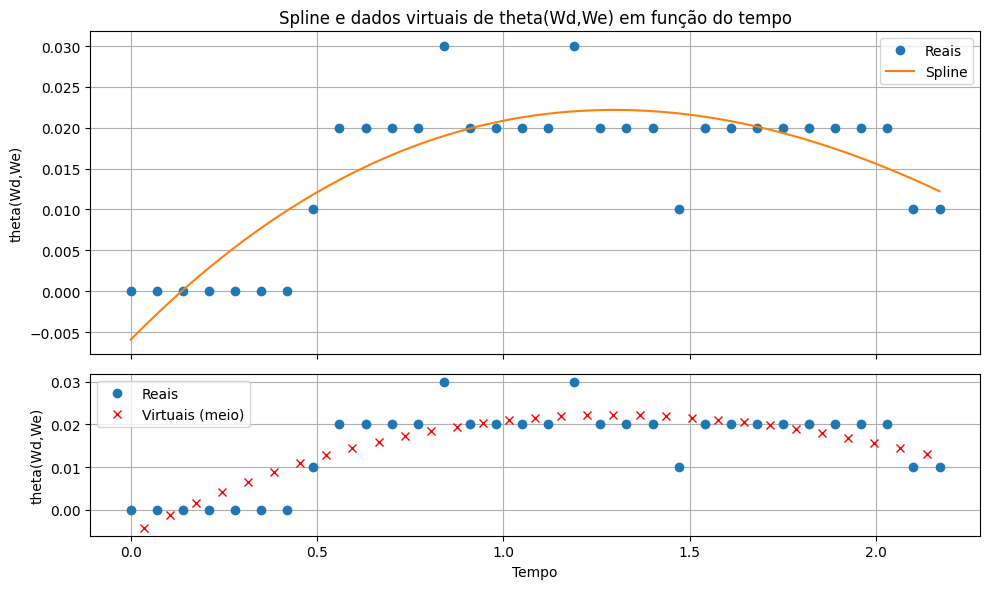

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# Carrega e prepara os dados
data = pd.read_csv("../content/Data.csv")
data = data.head(32)
data = data.drop(columns=["VD", "VE", "tempo"])
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data = data.rename(columns={
    "Setpoint VD": "Wd",
    "Setpoint VE": "We",
    "Theta": "theta(Wd,We)",
    "X": "x(Wd,We)",
    "Y": "y(Wd,We)",
})

# Extrai o tempo
tempo = data.index.to_numpy()

# Dicionário para armazenar os splines
splines = {}

# Faz spline de cada variável em função do tempo
for col in ["Wd", "We", "theta(Wd,We)"]:
    y = data[col].to_numpy()
    spline = UnivariateSpline(tempo, y, s=0.5)
    splines[col] = spline

    # Gera malha mais fina para visualização do spline
    tempo_fino = np.linspace(tempo.min(), tempo.max(), 1000)
    y_interp = spline(tempo_fino)

    # Gera amostras virtuais no centro entre pares de tempo
    tempo_virtual = (tempo[:-1] + tempo[1:]) / 2
    y_virtual = spline(tempo_virtual)
    # Visualização com subplots
    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    
    # Parte 1: spline + dados reais
    axs[0].plot(tempo, y, 'o', label='Reais')
    axs[0].plot(tempo_fino, y_interp, '-', label='Spline')
    axs[0].set_ylabel(col)
    axs[0].set_title(f"Spline e dados virtuais de {col} em função do tempo")
    axs[0].legend()
    axs[0].grid(True)

    # Parte 2: posições reais e virtuais no tempo
    axs[1].plot(tempo, y, 'o', label='Reais')
    axs[1].plot(tempo_virtual, y_virtual, 'x', color='red', label='Virtuais (meio)')
    axs[1].set_xlabel("Tempo")
    axs[1].set_ylabel(col)
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
tempo_virtual = (tempo[:-1] + tempo[1:]) / 2
wd_virtual = splines["Wd"](tempo_virtual)
we_virtual = splines["We"](tempo_virtual)
theta_virtual = splines["theta(Wd,We)"](tempo_virtual)

# Criar DataFrame com dados reais
df_reais = pd.DataFrame({
    "tempo": tempo,
    "Wd": data["Wd"].values,
    "We": data["We"].values,
    "theta(Wd,We)": data["theta(Wd,We)"].values,
})

# Criar DataFrame com dados virtuais
df_virtuais = pd.DataFrame({
    "tempo": tempo_virtual,
    "Wd_virtual": wd_virtual,
    "We_virtual": we_virtual,
    "theta_virtual": theta_virtual
})

# deslocar 2 time staps
df_virtuais["theta_virtual"] = df_virtuais["theta_virtual"].shift(1)


# Exportar para Excel com duas abas
with pd.ExcelWriter("dados_spline_reais_virtuais.xlsx") as writer:
    df_reais.to_excel(writer, sheet_name="Reais", index=False)
    df_virtuais.to_excel(writer, sheet_name="Virtuais", index=False)


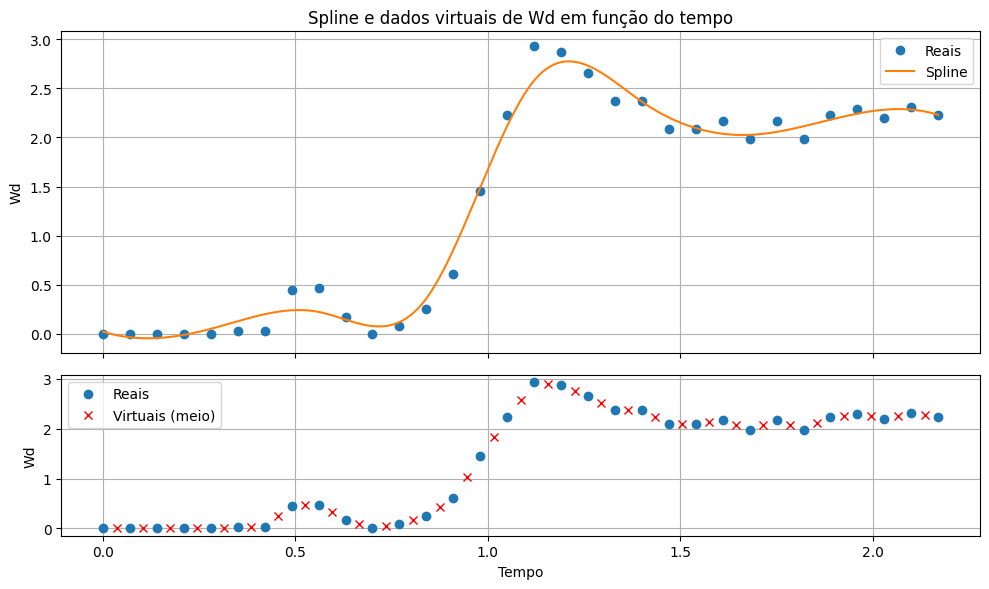

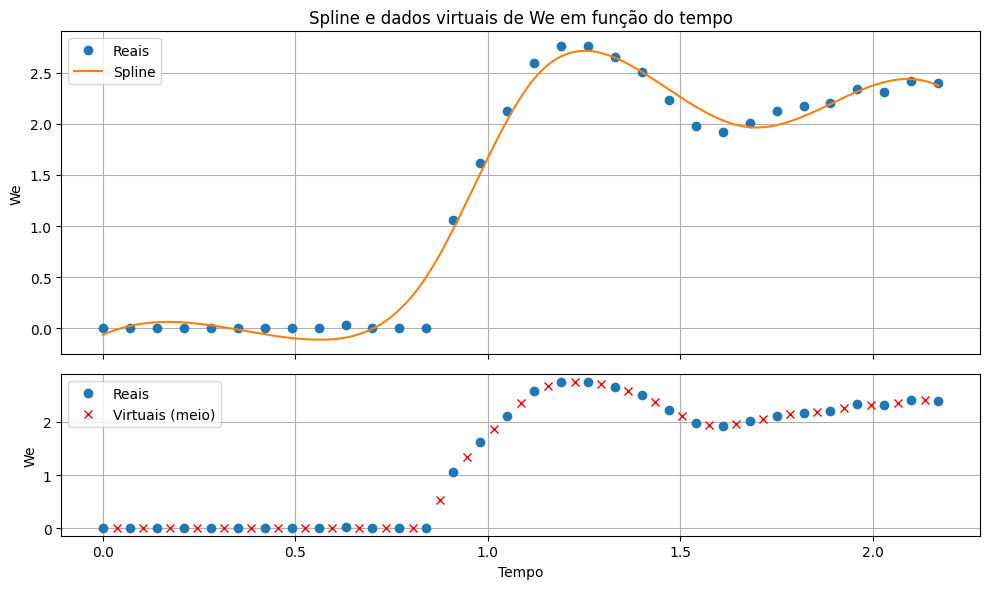

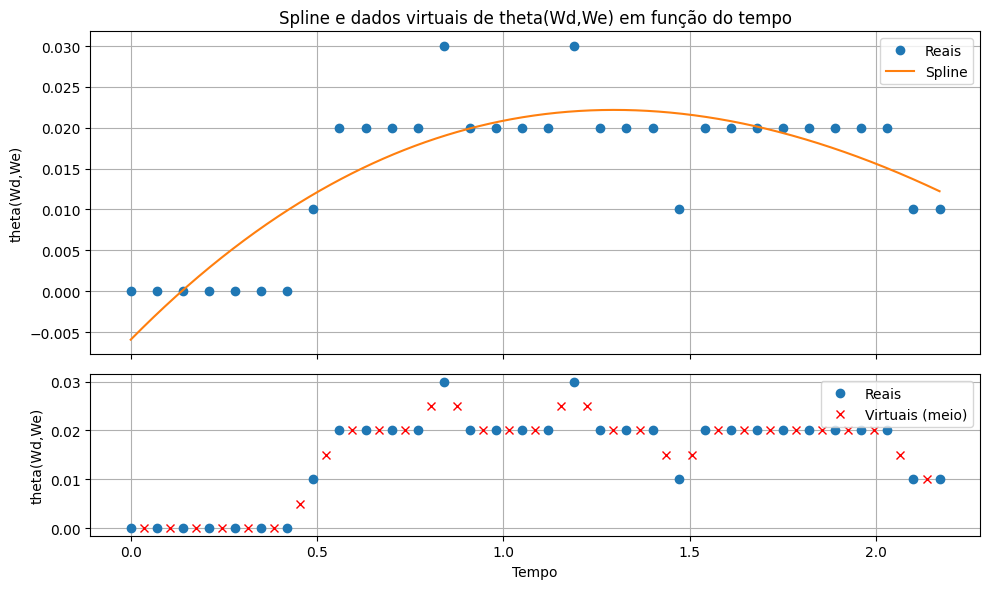

In [2]:
# Dicionário para armazenar os splines
splines = {}

# Faz spline de cada variável em função do tempo
for col in ["Wd", "We", "theta(Wd,We)"]:
    y = data[col].to_numpy()
    spline = UnivariateSpline(tempo, y, s=0.5)
    splines[col] = spline

    # Gera malha mais fina para visualização do spline
    tempo_fino = np.linspace(tempo.min(), tempo.max(), 1000)
    y_interp = spline(tempo_fino)

    # Gera amostras virtuais no centro entre pares de tempo
    tempo_virtual = (tempo[:-1] + tempo[1:]) / 2
    y_virtual = (y[:-1] + y[1:]) / 2 
    # y_virtual = spline(tempo_virtual)
    # Visualização com subplots
    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    
    # Parte 1: spline + dados reais
    axs[0].plot(tempo, y, 'o', label='Reais')
    axs[0].plot(tempo_fino, y_interp, '-', label='Spline')
    axs[0].set_ylabel(col)
    axs[0].set_title(f"Spline e dados virtuais de {col} em função do tempo")
    axs[0].legend()
    axs[0].grid(True)

    # Parte 2: posições reais e virtuais no tempo
    axs[1].plot(tempo, y, 'o', label='Reais')
    axs[1].plot(tempo_virtual, y_virtual, 'x', color='red', label='Virtuais (meio)')
    axs[1].set_xlabel("Tempo")
    axs[1].set_ylabel(col)
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()
